In [1]:
import networkx as nx 
import numpy as np 
import pylab as plt 
import json 
import os

In [2]:
import os
def rename_files_in_directory(root_dir, rename_dict):
    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            old_path = os.path.join(dirpath, filename)
            new_filename = filename

            # Apply all dictionary replacements to filename
            for old, new in rename_dict.items():
                new_filename = new_filename.replace(old, new)

            if new_filename != filename:
                new_path = os.path.join(dirpath, new_filename)
                try:
                    os.rename(old_path, new_path)
                    print(f"Renamed: {old_path} → {new_path}")
                except Exception as e:
                    print(f"Error renaming {old_path}: {e}")


rename_dict = {    
    "Poster Method": "Semantic",
    "UnionGraph - Fruchtermann": "Union_FR",
    "UnionGraph - UMAP": "Union_UMAP", 
    "Two Layer + Procrustes Alignment (Author Proxy)": "Independent_SA}",
    "Independent_SA}": "Independent_SA",
    "Two Layer + Procrustes Alignment (Paper Proxy)": "Independent_RA",
}
rename_files_in_directory("outputs", rename_dict)

In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({'font.size': 24})

def draw(G,X,rich,sparse,name, alg):
    name = name.capitalize()

    fig = plt.figure(figsize=(10, 6))
    gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[2, 1])


    # Left column (tall plot spanning both rows)
    ax1 = plt.subplot(gs[:, 0])
    ax1.set_title(f"{name.replace('_graph', '')} {alg}")
    ax1.set_xticks([])
    ax1.set_yticks([])

    for u,v in G.edges():
        ax1.plot([X[u,0], X[v,0]], [X[u,1], X[v,1]],c='grey', alpha=0.2, linewidth=0.5,zorder=1)

    ax1.scatter(X[sparse,0], X[sparse,1],c="tab:blue",s=5,zorder=2,alpha=0.6)
    ax1.scatter(X[rich,0], X[rich, 1],c='tab:orange',s=10,zorder=3,alpha=0.6)

    # Right column, top
    ax2 = plt.subplot(gs[0, 1])
    ax2.set_title("Rich")
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.scatter(X[rich,0], X[rich, 1],c='tab:orange',s=10,zorder=3,alpha=0.6)


    # Right column, bottom
    ax3 = plt.subplot(gs[1, 1])
    ax3.set_title("Sparse")
    ax3.set_xticks([])
    ax3.set_yticks([])
    ax3.scatter(X[sparse,0], X[sparse,1],c="tab:blue",s=5,zorder=2,alpha=0.6)


    plt.tight_layout()
    return fig, (ax1,ax2,ax3)

KeyboardInterrupt: 

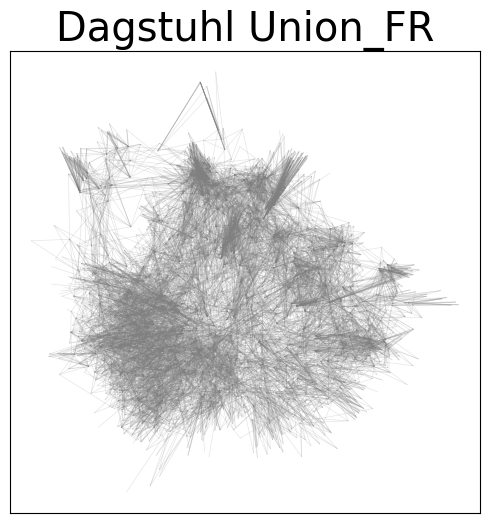

In [8]:
if not os.path.isdir("figures"):
    os.mkdir("figures")

if not os.path.isdir("figures/graph_pdfs"):
    os.mkdir("figures/graph_pdfs")
for gname in os.listdir("outputs"):
    for algname in os.listdir(f"outputs/{gname}"):
        with open(f"outputs/{gname}/{algname}", 'r') as fdata:
            data = json.load(fdata)

        G = nx.node_link_graph(data)
        G = nx.convert_node_labels_to_integers(G)

        X = np.zeros((G.number_of_nodes(), 2),np.float32)
        rich = set()
        sparse = set()
        for i,v in enumerate(G.nodes()):
            X[v,0] = G.nodes[v]['x']
            X[v,1] = G.nodes[v]['y']

            if G.nodes[v]['type'] == 'rich': rich.add(v)
            else: sparse.add(v)

        rich = list(rich)
        sparse = list(sparse)

        fig, axes = draw(G,X,rich,sparse,gname, algname.replace(".json", ""))

        # fig.set_size_inches(12,10)
        if not os.path.isdir(f"figures/graph_pdfs/{gname}"):
            os.mkdir(f"figures/graph_pdfs/{gname}")
        fig.savefig(f"figures/graph_pdfs/{gname}/{algname.replace('.json', '.png')}",dpi=150)
        plt.close(fig)
        # print(0 / 0)


In [ ]:
sstring = r'''
    \begin{figure}[ht]
    \centering
    \begin{minipage}[c]{0.32\textwidth}
        \includegraphics[width=\linewidth]{figures/graph_pdfs/dagstuhl/Union_FR.png}
        \includegraphics[width=\linewidth]{figures/graph_pdfs/dagstuhl/Union_UMAP.png}
    \end{minipage}%
    \hfill
    \begin{minipage}[c]{0.32\textwidth}
        \includegraphics[width=\linewidth]{figures/graph_pdfs/dagstuhl/Independent_SA.png}
        \includegraphics[width=\linewidth]{figures/graph_pdfs/dagstuhl/Independent_RA.png}
    \end{minipage}%
    \hfill
    \begin{minipage}[c]{0.32\textwidth}
        \includegraphics[width=\linewidth]{figures/graph_pdfs/dagstuhl/Semantic.png}
    \end{minipage}

    \parbox[c]{0.32\textwidth}{\centering (a)}
    \parbox[c]{0.32\textwidth}{\centering (b)}
    \parbox[c]{0.32\textwidth}{\centering (c)}    
    
    \caption{Example layouts of the dagstuhl data.}
    \label{fig:dagstuhl}
\end{figure}'''


print(sstring)


    \begin{figure}[ht]
    \centering
    \begin{minipage}[c]{0.32\textwidth}
        \includegraphics[width=\linewidth]{figures/graph_pdfs/dagstuhl/Union_FR.png}
        \includegraphics[width=\linewidth]{figures/graph_pdfs/dagstuhl/Union_UMAP.png}
    \end{minipage}%
    \hfill
    \begin{minipage}[c]{0.32\textwidth}
        \includegraphics[width=\linewidth]{figures/graph_pdfs/dagstuhl/Independent_SA.png}
        \includegraphics[width=\linewidth]{figures/graph_pdfs/dagstuhl/Independent_RA.png}
    \end{minipage}%
    \hfill
    \begin{minipage}[c]{0.32\textwidth}
        \includegraphics[width=\linewidth]{figures/graph_pdfs/dagstuhl/Semantic.png}
    \end{minipage}

    \parbox[c]{0.32\textwidth}{\centering (a)}
    \parbox[c]{0.32\textwidth}{\centering (b)}
    \parbox[c]{0.32\textwidth}{\centering (c)}    
    
    \caption{Example layouts of the dagstuhl data.}
    \label{fig:dagstuhl}
\end{figure}


In [ ]:
for graphname in os.listdir("outputs"):
    print(sstring.replace("dagstuhl", graphname))
    print()


    \begin{figure}[ht]
    \centering
    \begin{minipage}[c]{0.32\textwidth}
        \includegraphics[width=\linewidth]{figures/graph_pdfs/dagstuhl/Union_FR.png}
        \includegraphics[width=\linewidth]{figures/graph_pdfs/dagstuhl/Union_UMAP.png}
    \end{minipage}%
    \hfill
    \begin{minipage}[c]{0.32\textwidth}
        \includegraphics[width=\linewidth]{figures/graph_pdfs/dagstuhl/Independent_SA.png}
        \includegraphics[width=\linewidth]{figures/graph_pdfs/dagstuhl/Independent_RA.png}
    \end{minipage}%
    \hfill
    \begin{minipage}[c]{0.32\textwidth}
        \includegraphics[width=\linewidth]{figures/graph_pdfs/dagstuhl/Semantic.png}
    \end{minipage}

    \parbox[c]{0.32\textwidth}{\centering (a)}
    \parbox[c]{0.32\textwidth}{\centering (b)}
    \parbox[c]{0.32\textwidth}{\centering (c)}    
    
    \caption{Example layouts of the dagstuhl data.}
    \label{fig:dagstuhl}
\end{figure}


    \begin{figure}[ht]
    \centering
    \begin{minipage}[c]{0.32\textwidth}
